#### NLP Embeddings Clustering

##### Context

You are tasked with analyzing two datasets:

1. BBC News dataset: Contains text data grouped into 5 categories: Business, Entertainment, Politics, Sport, and Tech.
2. 20NewsGroups dataset: Contains text data grouped into 20 topics.

The goal is to transform the data into word embeddings, apply clustering techniques, and evaluate the results. Improve the results by using PCA for dimensionality reduction.

##### Problem Statement

Cluster the articles in both datasets using the following methods:

1. Feature extraction: Use TF-IDF, FastText, and Word2Vec to create embeddings.
2. Clustering algorithms: Implement K-Means, HDBSCAN, and Agglomerative Clustering.
3. Evaluation metrics: Evaluate the clustering results using NMI (Normalized Mutual Information), ARI (Adjusted Rand Index), AMI (Adjusted Mutual Information), and the Silhouette Score or Elbow Method.

##### Loading Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import emoji
import nltk
import spacy
import string
from nltk.corpus import stopwords
from collections import Counter
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.lda_model
from pyLDAvis import prepare

from gensim.models import Word2Vec 
from sklearn.feature_extraction.text import TfidfVectorizer 
from gensim.models import FastText 

import hdbscan
from hdbscan import HDBSCAN
from sklearn.metrics.pairwise import cosine_distances
from sklearn.cluster import KMeans 
from sklearn.cluster import AgglomerativeClustering #Agglomerative
from scipy.cluster.hierarchy import linkage, dendrogram #Agglomerative
from scipy.cluster.hierarchy import fcluster #Agglomerative
from collections import Counter #Agglomerative_points_to_clusters
from sklearn.metrics import silhouette_score

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split 
from sklearn.datasets import make_blobs 
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score

###### Expanding column width to see the full sentences in dataframes

In [2]:
pd.set_option('display.max_colwidth', None)

###### Muting Pandas Slice Warnings

In [3]:
pd.options.mode.chained_assignment = None

#### Loading Datasets

###### Loading 20newsgroups dataset

In [4]:
#Loading good 10% of 20newsgroups
data_20newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
documents_20newsgroups = data_20newsgroups.data
labels_20newsgroups = data_20newsgroups.target
labels_names_20newsgroups = data_20newsgroups.target_names
news_dict = {
    'label': labels_20newsgroups,
    'comment': documents_20newsgroups,
}
news_df = pd.DataFrame(news_dict)
news_df['label_name'] = news_df['label'].apply(lambda x: labels_names_20newsgroups[x])

_, x_test_news, _, y_test_news = train_test_split(
    news_df,
    news_df['label'],
    test_size=0.1,
    random_state=42,
    stratify=news_df['label']
)

#Using the x_test_news
full_df_20newsgroups = x_test_news.copy()
#----------------------------------------------------------------------------

#Renaming columns for clarity of Column names
columns_mapping = {'label':'ground_truth_label','comment': 'sentence','label_name':'category'}
#Applying the renaming of Columns
full_df_20newsgroups = full_df_20newsgroups.rename(columns=columns_mapping)

#Cleaning Columns names (strip whitespace) & creating a relevant Columns list
full_df_20newsgroups.columns = full_df_20newsgroups.columns.str.strip()
full_df_20newsgroups_columns = list(full_df_20newsgroups.columns)
print("Cleaning Columns of 20newsgroups DataFrame & putting them in full_df_20newsgroups_columns list")
print(full_df_20newsgroups_columns)
print('\n')

#display(full_df_20newsgroups.head())

Cleaning Columns of 20newsgroups DataFrame & putting them in full_df_20newsgroups_columns list
['ground_truth_label', 'sentence', 'category']




###### Loading bbc_news dataset

In [5]:
#Loading all the bbc news dataset from relevant csv file
df_bbcnews_org = pd.read_csv("../data/bbc_news_test.csv")
#display(df_bbcnews.head())

full_df_bbcnews = df_bbcnews_org.copy()

#----------------------------------------------------------------------------

#Renaming columns for clarity of Column names
columns_mapping = {'ArticleId':'id', 'Text':'sentence','Category':'category'}

#Applying the renaming of Columns
full_df_bbcnews = full_df_bbcnews.rename(columns=columns_mapping)

#Cleaning Columns names (strip whitespace) & creating a relevant Columns list
full_df_bbcnews.columns = full_df_bbcnews.columns.str.strip()
full_df_bbcnews_columns = list(full_df_bbcnews.columns)
print("Cleaning Columns of bbc_news DataFrame & putting them in full_df_bbcnews_columns list")
print(full_df_bbcnews_columns)

#display(full_df_bbcnews.head())

Cleaning Columns of bbc_news DataFrame & putting them in full_df_bbcnews_columns list
['id', 'sentence', 'category']


#### Cleaning & EDA for Datasets

##### Cleaning & EDA for 20newsgroups dataframe

##### Selecting values from desired column "sentence" for text EDA of 20newsgroups

In [6]:
df_sentence_20newsgroups = full_df_20newsgroups[["sentence"]].copy()
df_sentence_20newsgroups["sentence"] = df_sentence_20newsgroups["sentence"].astype(str)
#display(full_df_20newsgroups.head())

#Creating the corpus for corpus_20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence"]

##### Visualizing Sentence Count for 20newsgroups

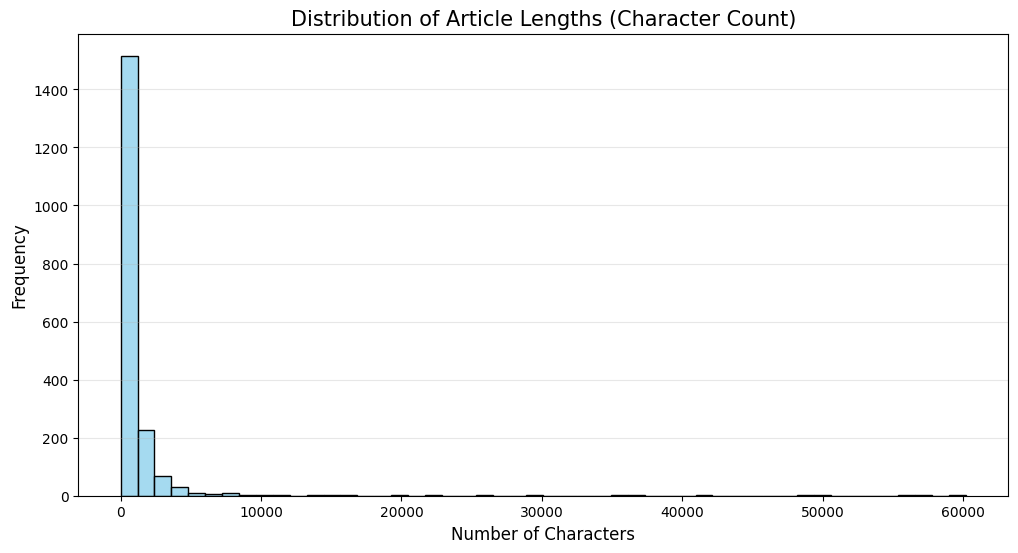

In [7]:
#Checking the number of characters present in each sentence to have a rough idea about the text headline length
#Calculating sentence lengths
df_sentence_20newsgroups["char_count"] = df_sentence_20newsgroups["sentence"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_sentence_20newsgroups["char_count"], bins=50, color="skyblue")
plt.title("Distribution of Article Lengths (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

##### Visualizing Word Count for 20newsgroups

Mean Word Count: 183.00
Median Word Count: 82.00


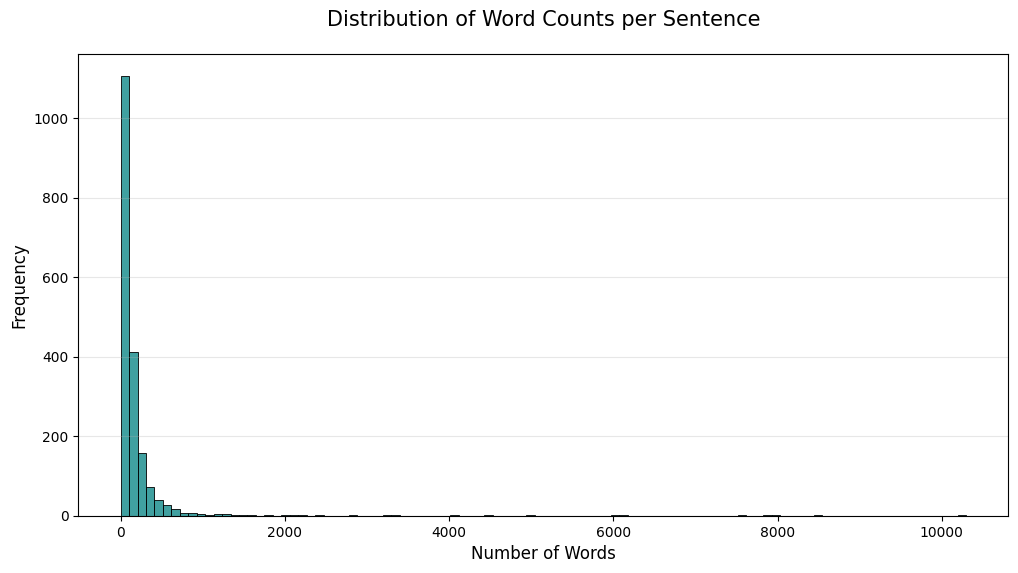

In [8]:
#Calculating word counts by splitting strings into lists
df_sentence_20newsgroups["word_count"] = df_sentence_20newsgroups["sentence"].str.split().str.len()

#Calculating key statistics
mean_words = df_sentence_20newsgroups["word_count"].mean().round()
median_words = df_sentence_20newsgroups["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_sentence_20newsgroups["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per Sentence", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Visualizing average word length in each Sentence for 20newsgroups

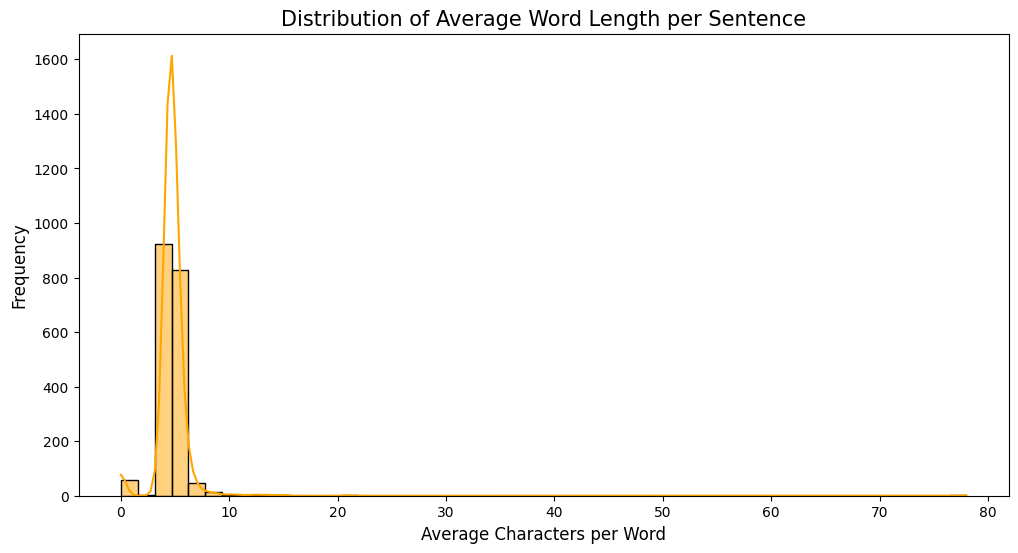

In [9]:
def get_avg_word_len(text):
    """Function to calculating average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df_sentence_20newsgroups['avg_word_len'] = df_sentence_20newsgroups['sentence'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_sentence_20newsgroups['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per Sentence", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

##### Ngram exploration for 20newsgroups

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

#Initializing the raw corpus
corpus = df_sentence_20newsgroups["sentence"]

#Extracting the top 10 for different n-gram ranges
top_unigrams = get_top_ngram(corpus, n=1)
top_bigrams = get_top_ngram(corpus, n=2)
top_trigrams = get_top_ngram(corpus, n=3)

print("Top 10 Unigrams (Raw):", top_unigrams)
print("Top 10 Bigrams (Raw):", top_bigrams)
print("Top 10 Trigrams (Raw):", top_trigrams)

Top 10 Unigrams (Raw): [('the', np.int64(17853)), ('to', np.int64(9048)), ('of', np.int64(7849)), ('and', np.int64(7177)), ('in', np.int64(5429)), ('is', np.int64(4716)), ('that', np.int64(4325)), ('it', np.int64(3873)), ('for', np.int64(3242)), ('you', np.int64(2938))]
Top 10 Bigrams (Raw): [('of the', np.int64(1898)), ('in the', np.int64(1431)), ('to the', np.int64(832)), ('on the', np.int64(713)), ('to be', np.int64(555)), ('for the', np.int64(516)), ('it is', np.int64(494)), ('and the', np.int64(483)), ('if you', np.int64(461)), ('that the', np.int64(424))]
Top 10 Trigrams (Raw): [('one of the', np.int64(104)), ('there is no', np.int64(80)), ('be able to', np.int64(75)), ('part of the', np.int64(64)), ('in order to', np.int64(60)), ('out of the', np.int64(57)), ('it would be', np.int64(55)), ('would like to', np.int64(54)), ('as well as', np.int64(53)), ('some of the', np.int64(53))]


##### Visualizing Top 10 Unigrams (Raw) for 20newsgroups

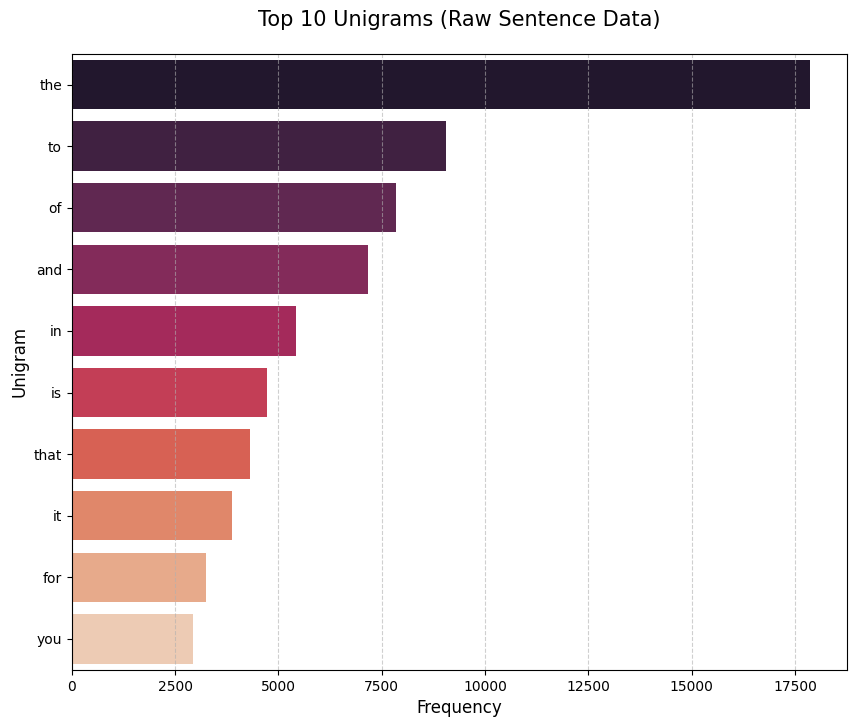

In [11]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_unigrams)

#Visualizing Top 10 Bigrams (Raw) for 20newsgroups
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Unigrams (Raw Sentence Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Unigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### Visualizing Top 10 Bigrams (Raw) for 20newsgroups

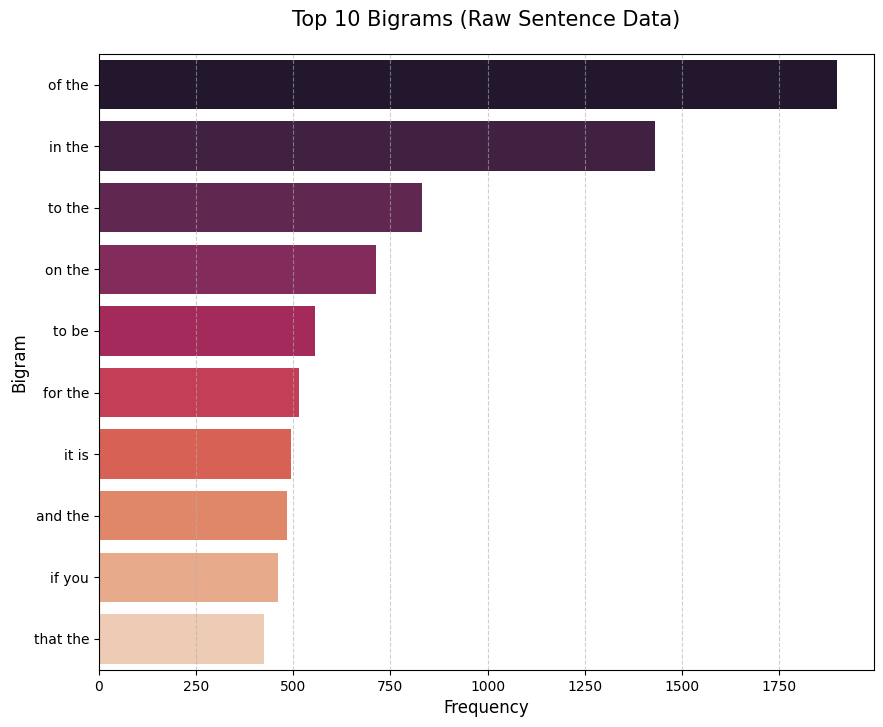

In [12]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_bigrams)

#Visualizing Top 10 Bigrams (Raw) for 20newsgroups
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Bigrams (Raw Sentence Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Bigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### Visualizing Top 10 Trigrams (Raw) for 20newsgroups

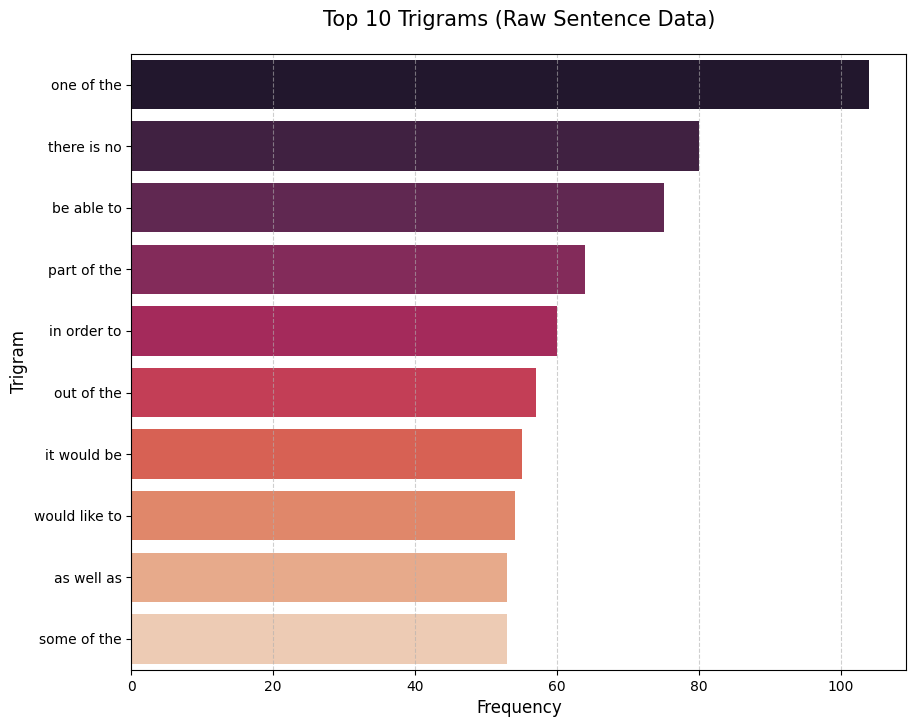

In [13]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_trigrams)

#Visualizing Top 10 Bigrams (Raw) for 20newsgroups
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Trigrams (Raw Sentence Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Trigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### Topic modeling exploration (Raw) for 20newsgroups

In [14]:
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model
from pyLDAvis import prepare

#Vectorizing the raw corpus
raw_corpus = df_sentence_20newsgroups["sentence"]
tf_vectorizer = CountVectorizer(stop_words=None)
tf = tf_vectorizer.fit_transform(raw_corpus)

#Initializing and fitting LDA
#Chose initial n_components=20 to have 20 broad topics,as ground truth is 20 categories 
lda_model = LatentDirichletAllocation(n_components=20, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Displaying the dashboard
pyLDAvis.display(panel)

##### Removal of HTML Tags like <'p> or <br'> & translating them into text in 20newsgroups raw text rows

In [15]:
from bs4 import BeautifulSoup

def remove_html_tags(text):
    """
    Removes HTML tags using BeautifulSoup. 
    If no tags are present, it returns the original text intact.
    """
    #check to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Parsing the text and extracting only the string content
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ", strip=True)

df_sentence_20newsgroups["sentence_no_html"] = df_sentence_20newsgroups["sentence"].apply(remove_html_tags)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_no_html"]

##### Removal of urls in 20newsgroups clean from htlml tags text rows

In [16]:
import re

def remove_urls(text):
    """
    Removes URLs from the text using regular expressions.
    If no URLs are present, it returns the original previous text intact.
    """
    #Checking to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Regex pattern to match http, https, and www URLs
    url_pattern = re.compile(r'http[s]?://\S+|www\.\S+')
    
    #Replacing the matched URLs with an empty string
    return url_pattern.sub(r'', text)

#Applying the URL removal to the text that just had HTML removed
df_sentence_20newsgroups["sentence_no_url"] = df_sentence_20newsgroups["sentence_no_html"].apply(remove_urls)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_no_url"]

##### Removal of Emoticons like :-) & translating them into text in 20newsgroups clean text rows

In [17]:
import re

#Creating a dictionary of common emoticons and their text translations
EMOTICON_DICT = {
    r':-\)': ' happy ', r':\)': ' happy ', r':-\]': ' happy ', r':\]': ' happy ',
    r':-\(': ' sad ', r':\(': ' sad ', r':-\[': ' sad ', r':\[': ' sad ',
    r':-D': ' laugh ', r':D': ' laugh ', r'XD': ' laugh ',
    r';-\)': ' wink ', r';\)': ' wink ',
    r':-P': ' playful ', r':P': ' playful '
}

def translate_emoticons(text):
    """Translates ASCII emoticons to words BEFORE punctuation is removed"""
    text = str(text)
    for emoticon, word in EMOTICON_DICT.items():
        text = re.sub(re.escape(emoticon), word, text, flags=re.IGNORECASE)
    return text

#Apply this to the raw text :
df_sentence_20newsgroups["after_emoticons_translation_sentence"] = df_sentence_20newsgroups["sentence_no_url"].apply(translate_emoticons)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["after_emoticons_translation_sentence"]

##### Removal of Emojis like 😀 & translating them into text in 20newsgroups clean text rows

In [18]:
import emoji

def translate_emoji_to_words(text):
    """Translates emojis into text aliases (e.g., 👍 becomes 'thumbs up')"""
    translated_text = emoji.demojize(str(text), delimiters=(" ", " "))
    
    #Replacing underscores with spaces so 'thumbs_up' for example becomes 'thumbs up'
    translated_text = translated_text.replace("_", " ")
    
    return translated_text

#Applying it to the latest cleaned text column
df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"] = df_sentence_20newsgroups["after_emoticons_translation_sentence"].apply(translate_emoji_to_words)

#Cleaning up any extra whitespace left behind
df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"] = df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"].str.replace(r'\s+', ' ', regex=True).str.strip()

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"]

# df_sentence_20newsgroups.head()

##### Removal of Punctuations & implementing lower casing in column "sentence" of 20newsgroups

- The string.punctuation in python contains the following punctuation symbols: !"#$%&\'()*+,-./:;<=>?@[\\]^_{|}~
- If needed we can add or remove more punctuations as per our need later.

In [19]:
PUNCT_TO_REMOVE = string.punctuation

def remove_punctuation_and_lower(text):
    """Custom function to remove punctuation and lowercase text"""
    return text.lower().translate(str.maketrans('', '', PUNCT_TO_REMOVE))

#Applying the function
df_sentence_20newsgroups["sentence_wo_punct_lower"] = df_sentence_20newsgroups["after_emojis_emoticons_translation_sentence"].apply(remove_punctuation_and_lower)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_wo_punct_lower"]

#display(df_sentence_20newsgroups.head())

##### Removal of stopwords in column "sentence_wo_punct_lower" of cleaned text of 20newsgroups

In [20]:
CHAT_WORDS_DICT = {
    "a3": "anytime anywhere anyplace", "adih": "another day in hell", "afk": "away from keyboard",
    "afaik": "as far as i know", "asap": "as soon as possible", "asl": "age sex location",
    "atk": "at the keyboard", "atm": "at the moment", "aka": "also known as", "approx": "approximately",
    "bae": "before anyone else", "bak": "back at keyboard", "bbl": "be back later", "bbs": "be back soon",
    "bfn": "bye for now", "b4n": "bye for now", "brb": "be right back", "bruh": "bro", 
    "brt": "be right there", "bsaaw": "big smile and a wink", "btw": "by the way", "b/c": "because",
    "bwl": "bursting with laughter", "csl": "can not stop laughing", "cu": "see you", 
    "cul8r": "see you later", "cya": "see you", "dm": "direct message", "eta": "estimated time of arrival",
    "eod": "end of day", "eow": "end of week", "faq": "frequently asked questions", 
    "fc": "fingers crossed", "fimh": "forever in my heart", "fomo": "fear of missing out", 
    "fr": "for real", "fwiw": "for what its worth", "fyp": "for you page", "fyi": "for your information", 
    "g9": "genius", "gal": "get a life", "gg": "good game", "gmta": "great minds think alike",
    "gn": "good night", "goat": "greatest of all time", "gr8": "great", "hbd": "happy birthday", 
    "hbu": "how about you", "ic": "i see", "icq": "i seek you", "idc": "i do not care",
    "idk": "i do not know", "iirc": "if i recall correctly", "ifyp": "i feel your pain", 
    "ilu": "i love you", "ily": "i love you", "imho": "in my humble opinion", "imu": "i miss you",
    "imo": "in my opinion", "iow": "in other words", "irl": "in real life",
    "iykyk": "if you know you know", "jk": "just kidding", "k": "okay", "kiss": "keep it simple stupid",
    "l": "loss", "l8r": "later", "ldr": "long distance relationship", "lmk": "let me know",
    "lmao": "laughing my ass off", "lol": "laughing out loud", "ltns": "long time no see",
    "m8": "mate", "mfw": "my face when", "mid": "mediocre", "mrw": "my reaction when",
    "mte": "my thoughts exactly", "n": "and", "nvm": "never mind", "nrn": "no reply necessary",
    "npc": "non player character", "oic": "oh i see", "op": "overpowered", "ootl": "out of the loop",
    "pita": "pain in the ass", "pov": "point of view", "prt": "party", "pls": "please", "plz": "please",
    "prw": "parents are watching", "r": "are", "rofl": "rolling on the floor laughing",
    "roflol": "rolling on the floor laughing out loud", 
    "rotflmao": "rolling on the floor laughing my ass off", "rn": "right now", 
    "sk8": "skate", "stats": "your sex and age", "sus": "suspicious", "tbh": "to be honest", 
    "tba": "to be announced", "tbd": "to be determined", "tbf": "to be fair",
    "tfw": "that feeling when", "thx": "thank you", 
    "tldr": "too long did not read", "tntl": "trying not to laugh", "ttfn": "ta ta for now", 
    "ttyl": "talk to you later", "u": "you", "u2": "you too", "u4e": "yours for ever", 
    "w": "win", "w8": "wait", "wb": "welcome back", "wbu": "what about you", "wtf": "what the fuck", 
    "wtg": "way to go", "wuf": "where are you from", "wyd": "what you doing", "w/": "with", 
    "w/o": "without", "wywh": "wish you were here", "y": "why", "zzz": "sleeping bored tired"
}

In [21]:
def chat_words_conversion(text):
    """
    Expands common abbreviations into full words.
    Checks each word against the dictionary.
    """
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    return " ".join([CHAT_WORDS_DICT.get(word, word) for word in text.split()])

df_sentence_20newsgroups["sentence_chat_wo_punct_lower"] = df_sentence_20newsgroups["sentence_wo_punct_lower"].apply(chat_words_conversion)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_chat_wo_punct_lower"]

##### Visualizing Top 15 Most Frequent Stopwords 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\roxan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


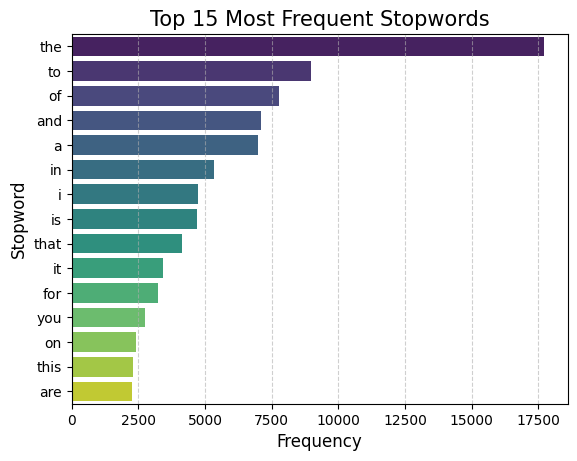

In [22]:
from nltk.corpus import stopwords
nltk.download('stopwords') #downloading list of English words
from collections import Counter

STOPWORDS = set(stopwords.words('english'))
manual_fixes = [word.replace("'", "") for word in STOPWORDS if "'" in word]
STOPWORDS.update(manual_fixes)

#Identifying which text column to analyze 
text_data = corpus_20newsgroups

#Extracting and count stopwords only
stopword_list = []
for text in text_data:
    words = str(text).split()
    stopword_list.extend([word for word in words if word in STOPWORDS])

#Getting the Top 15
stopword_counts = Counter(stopword_list).most_common(15)
words, counts = zip(*stopword_counts)

#Visualizing Top 15 Most Frequent Stopwords 
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)

plt.title("Top 15 Most Frequent Stopwords", fontsize=15)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Stopword", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

##### Removal of stopwords in column "sentence_wo_punct_lower" of 20newsgroups

In [23]:
def remove_stopwords(text):
    """custom function to remove the stopwords"""
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"] = df_sentence_20newsgroups["sentence_chat_wo_punct_lower"].apply(remove_stopwords)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"]

#display(df_sentence_20newsgroups.head())

##### Dropping not needed columns 

In [24]:
#Dropping the two previously created columns that are no longer needed 
df_sentence_20newsgroups.drop(["char_count","word_count","sentence_no_html","sentence_no_url","after_emoticons_translation_sentence","after_emojis_emoticons_translation_sentence","sentence_chat_wo_punct_lower"], axis=1, inplace=True)

##### Removal of Frequent words of 20newsgroups cleaned text rows

In [25]:
from collections import Counter
cnt = Counter()
for text in df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"].values:
    for word in text.split():
        cnt[word] += 1
        
print(cnt.most_common(10))

#print(' ')
#print('Alternative way to find the top_10_words using pandas:')
#top_10_words = df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"].str.split().explode().value_counts().head(10)
#print(top_10_words)

[('x', 1721), ('one', 1007), ('would', 974), ('get', 637), ('like', 617), ('people', 612), ('use', 567), ('also', 567), ('know', 531), ('time', 510)]


In [26]:
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
def remove_freqwords(text):
    """custom function to remove the frequent words"""
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

df_sentence_20newsgroups["sentence_wo_freq_stopwords_punct_lower"] = df_sentence_20newsgroups["sentence_wo_stopwords_punct_lower"].apply(lambda text: remove_freqwords(text))

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_wo_freq_stopwords_punct_lower"]

#display(df_sentence_20newsgroups.head())

##### Dropping not needed columns 

In [27]:
#Dropping the two previously created columns that are no longer needed 
df_sentence_20newsgroups.drop(["sentence_wo_punct_lower", "sentence_wo_stopwords_punct_lower"], axis=1, inplace=True)

##### Removal of Rare words of 20newsgroups cleaned text rows

In [28]:
#Defining the min_freq_threshold for removal of words appearing fewer than X times
min_freq_threshold = 2

#Identifying all words that don't meet the threshold
RAREWORDS = set([word for word, count in cnt.items() if count < min_freq_threshold])
print(f"Number of unique rare words to remove: {len(RAREWORDS)}")
print(f"Sample of words appearing only once (to be removed):")
for word in list(RAREWORDS)[:20]:
    print(f"{word}: {cnt[word]}")

#Defining the cleaning function
def remove_rarewords(text):
    """Removes words that appear fewer than the threshold frequency"""
    if pd.isna(text) or not isinstance(text, str):
        return text
    return " ".join([word for word in text.split() if word not in RAREWORDS])

df_sentence_20newsgroups["sentence_wo_rare_freq_stopwords_punct_lower"] = df_sentence_20newsgroups["sentence_wo_freq_stopwords_punct_lower"].apply(remove_rarewords)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["sentence_wo_rare_freq_stopwords_punct_lower"]

#display(df_sentence_20newsgroups.head())

Number of unique rare words to remove: 16185
Sample of words appearing only once (to be removed):
electrostatic: 1
3362: 1
noam: 1
incurable: 1
indepedent: 1
prep: 1
exagerate: 1
nonrendering: 1
uncivilized: 1
deplibs1: 1
hasha: 1
20s: 1
39364681989: 1
liquidimageable: 1
514: 1
figaro: 1
drastamat: 1
variaty: 1
trapezemounted: 1
jansen: 1


##### Lemmatization in 20newsgroups cleaned text rows

In [29]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
#Downloading the required WordNet data
nltk.download('wordnet', quiet=True) 
nltk.download('omw-1.4', quiet=True) 
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """Custom function to lemmatize text """
    return " ".join([lemmatizer.lemmatize(word) for word in str(text).split()])

#Applying function to the fully cleaned column and creating a new column with lematized cleaned text data
df_sentence_20newsgroups["lemmatized_cleaned_sentence"] = df_sentence_20newsgroups["sentence_wo_rare_freq_stopwords_punct_lower"].apply(lemmatize_text)

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["lemmatized_cleaned_sentence"]

#display(df_sentence_20newsgroups[["sentence_wo_rare_freq_stopwords_punct_lower", "lemmatized_cleaned_sentence"]].head())

##### Developping lemmatization of text in 20newsgroups cleaned text rows by using POS tagging

In [30]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

#Downloading the required wordnet data & POS tagger model
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

#Mapping nltk POS tags to WordNet POS tags
wordnet_map = {"N": wordnet.NOUN, "V": wordnet.VERB, "J": wordnet.ADJ, "R": wordnet.ADV}

def lemmatize_words(text):
    """Custom function to develop lemmatization of text by using POS tagging"""
    pos_tagged_text = nltk.pos_tag(str(text).split())
    return " ".join([lemmatizer.lemmatize(word, wordnet_map.get(pos[0], wordnet.NOUN)) for word, pos in pos_tagged_text])

df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"] = df_sentence_20newsgroups["sentence_wo_rare_freq_stopwords_punct_lower"].apply(lambda text: lemmatize_words(text))

#Updating corpus of 20newsgroups
corpus_20newsgroups=df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"]

#Display the before and after the POS tagging in lematization
#display(df_sentence_20newsgroups[["sentence_wo_rare_freq_stopwords_punct_lower", "final_lemmatized_cleaned_sentence"]].head())

#Checking all columns in df_sentence_20newsgroups
#df_sentence_20newsgroups

#Dropping not needed any more columns in df_sentence_20newsgroups
df_sentence_20newsgroups.drop(["sentence_wo_freq_stopwords_punct_lower", "sentence_wo_rare_freq_stopwords_punct_lower","lemmatized_cleaned_sentence"], axis=1, inplace=True)

#Checking updated columns in df_sentence_20newsgroups
#df_sentence_20newsgroups

##### Checking Nulls of final cleaned column "final_lemmatized_cleaned_sentence" of 20newsgroups & dropping cleaned text null rows

In [31]:
#Checking for null values
null_count = df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"].isna().sum()
print(f"Number of null values in finally cleaned text column : {null_count}")

#Initial rows before dropping null values
print(f"Rows before dropping null values in finally cleaned text column: {len(df_sentence_20newsgroups)}")

#Drupping null values
df_sentence_20newsgroups.dropna(subset=["final_lemmatized_cleaned_sentence"], inplace=True)

#Rows after dropping null values and before dropping duplicate values
print(f"Rows after dropping null values and before dropping duplicate values in finally cleaned text column: {len(df_sentence_20newsgroups)}")

#Keeping only rows where the cleaned text of column "final_lemmatized_cleaned_sentence" has length greater than 0
df_sentence_20newsgroups = df_sentence_20newsgroups[df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "final_lemmatized_cleaned_sentence"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_sentence_20newsgroups)}")

#Updating corpus
corpus_20newsgroups=df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"]

Number of null values in finally cleaned text column : 0
Rows before dropping null values in finally cleaned text column: 1885
Rows after dropping null values and before dropping duplicate values in finally cleaned text column: 1885
Rows after removing empty rows in finally cleaned text column: 1821


##### Visualizing updated Top 5 Most Frequent Stopwords (should be zero)

In [32]:
from nltk.corpus import stopwords
from collections import Counter

#Updating the standard set with de-punctuated versions
STOPWORDS = set(stopwords.words('english'))
manual_fixes = [word.replace("'", "") for word in STOPWORDS if "'" in word]
STOPWORDS.update(manual_fixes)

#Defining a robust cleaning function
def final_clean_check(text):
    #Ensuring string type, lowercase, and split on any whitespace
    return " ".join([word for word in str(text).lower().split() if word not in STOPWORDS])

#Re-applying to the dataframe and updating the corpus variable
df_sentence_20newsgroups["sentence_final_clean"] = df_sentence_20newsgroups["final_lemmatized_cleaned_sentence"].apply(final_clean_check)

#Updating corpus
corpus_20newsgroups = df_sentence_20newsgroups["sentence_final_clean"]

#Running the counting logic on the updated final corpus
text_data = corpus_20newsgroups
stopword_list = []
for text in text_data:
    words = text.split()
    stopword_list.extend([word for word in words if word in STOPWORDS])

#Plotting the results if stopwords exist
if not stopword_list:
    print("Success! No standard stopwords detected.")
else:
    stopword_counts = Counter(stopword_list).most_common(15)
    words, counts = zip(*stopword_counts)
    plt.figure(figsize=(10, 8))
    sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)
    plt.title("Remaining Stopwords After Check", fontsize=15)
    plt.show()

Success! No standard stopwords detected.


##### Visualizing updated Top 15 Most Frequent Words 

In [33]:
top_15_words = df_sentence_20newsgroups["sentence_final_clean"].str.split().explode().value_counts().head(15)
print(top_15_words)

sentence_final_clean
make      702
say       685
go        652
think     630
use       572
see       534
work      487
may       486
come      483
take      476
could     455
good      445
want      427
system    425
file      422
Name: count, dtype: int64


##### Adding domain-specific noise words into the existing STOPWORDS set & removing them

In [34]:
#Defining domain-specific noise words
domain_stopwords = ['x', 'one', 'would', 'get', 'dont', 'like', 'people', 'use', 'also', 'eyes']

#Adding them into the existing STOPWORDS set
STOPWORDS.update(domain_stopwords)

#Removing those noise words from the corpus 
def remove_domain_noise(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df_sentence_20newsgroups["final_clean_corpus"] = df_sentence_20newsgroups["sentence_final_clean"].apply(remove_domain_noise)

#Updating corpus
corpus_20newsgroups = df_sentence_20newsgroups["final_clean_corpus"]

##### Visualizing again updated Top 15 Most Frequent Words 

In [35]:
top_15_words = df_sentence_20newsgroups["final_clean_corpus"].str.split().explode().value_counts().head(15)
print(top_15_words)

final_clean_corpus
make      702
say       685
go        652
think     630
see       534
work      487
may       486
come      483
take      476
could     455
good      445
want      427
system    425
file      422
way       416
Name: count, dtype: int64


##### Ngram exploration for Final cleaned corpus of 20newsgroups

In [36]:
#Extracting the top 10 for cleaned n-gram ranges
top_unigrams_clean = get_top_ngram(corpus_20newsgroups, n=1)
top_bigrams_clean = get_top_ngram(corpus_20newsgroups, n=2)
top_trigrams_clean = get_top_ngram(corpus_20newsgroups, n=3)

#Printing the results to see the shift in content
print("Top 10 Cleaned Unigrams:", top_unigrams_clean)
print("Top 10 Cleaned Bigrams:", top_bigrams_clean)
print("Top 10 Cleaned Trigrams:", top_trigrams_clean)

Top 10 Cleaned Unigrams: [('make', np.int64(702)), ('say', np.int64(685)), ('go', np.int64(652)), ('think', np.int64(630)), ('see', np.int64(534)), ('work', np.int64(487)), ('may', np.int64(486)), ('come', np.int64(483)), ('take', np.int64(476)), ('could', np.int64(455))]
Top 10 Cleaned Bigrams: [('ask question', np.int64(80)), ('frequently ask', np.int64(68)), ('new york', np.int64(53)), ('window manager', np.int64(46)), ('united state', np.int64(44)), ('send request', np.int64(42)), ('year ago', np.int64(41)), ('last year', np.int64(40)), ('hard drive', np.int64(40)), ('south georgia', np.int64(38))]
Top 10 Cleaned Trigrams: [('frequently ask question', np.int64(67)), ('south georgia island', np.int64(28)), ('25 mhz operational', np.int64(19)), ('professor history university', np.int64(18)), ('hicnet medical newsletter', np.int64(15)), ('medical newsletter page', np.int64(15)), ('volume number 10', np.int64(15)), ('number 10 april', np.int64(15)), ('10 april 20', np.int64(15)), ('apr

##### Visualizing Top 10 Unigrams (Final Cleaned corpus) for 20newsgroups

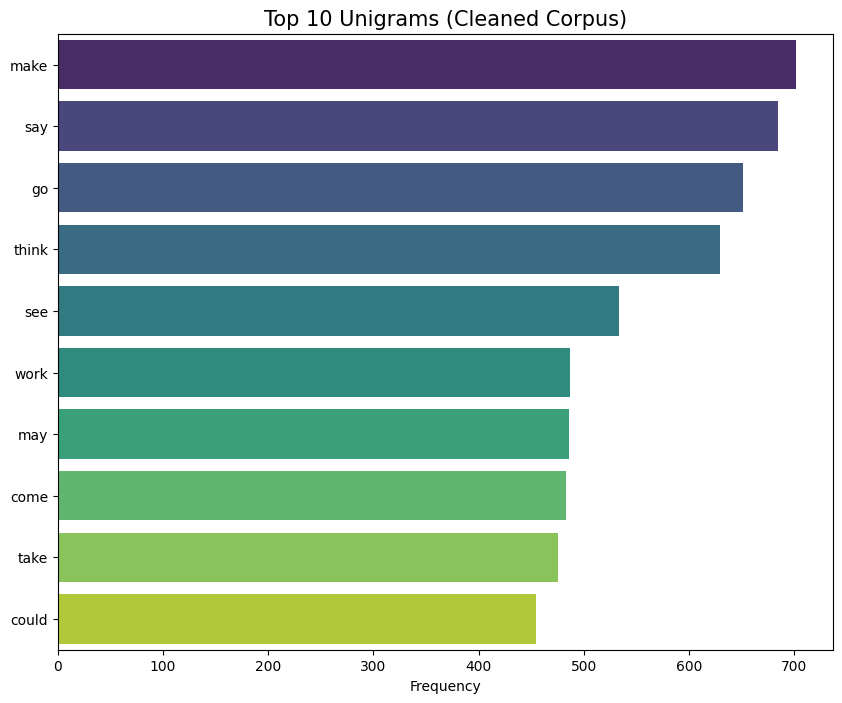

In [37]:
#Plotting Top 10 final cleaned corpus Unigrams
words, counts = zip(*top_unigrams_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)
plt.title("Top 10 Unigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Visualizing Top 10 Bigrams (Final Cleaned corpus) for 20newsgroups

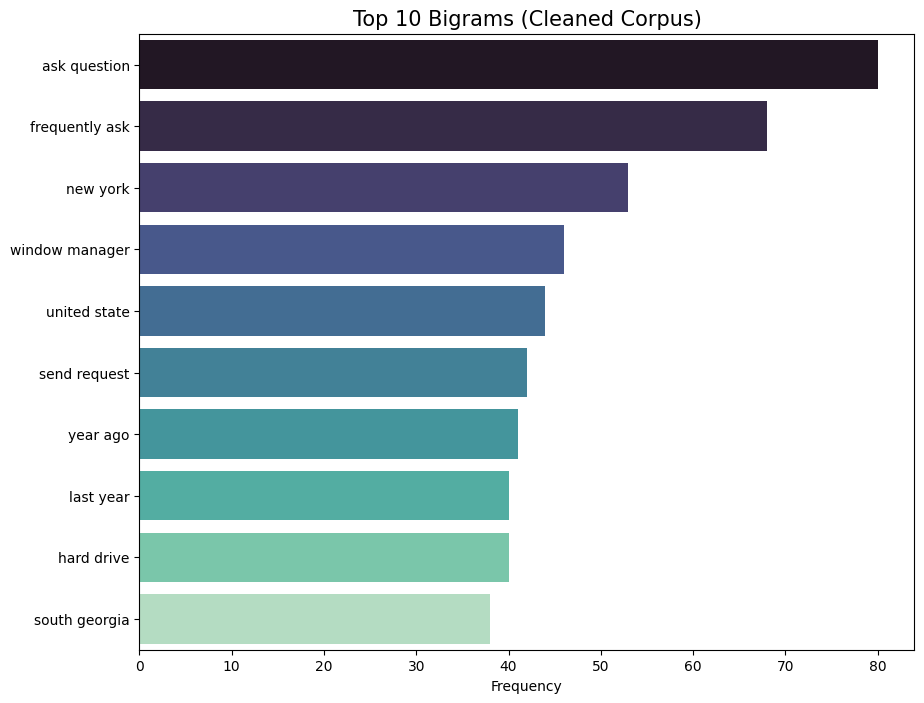

In [38]:
#Plotting Top 10 final cleaned corpus Bigrams
words, counts = zip(*top_bigrams_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="mako", legend=False)
plt.title("Top 10 Bigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### Visualizing Top 10 Trigrams (Final Cleaned corpus) for 20newsgroups

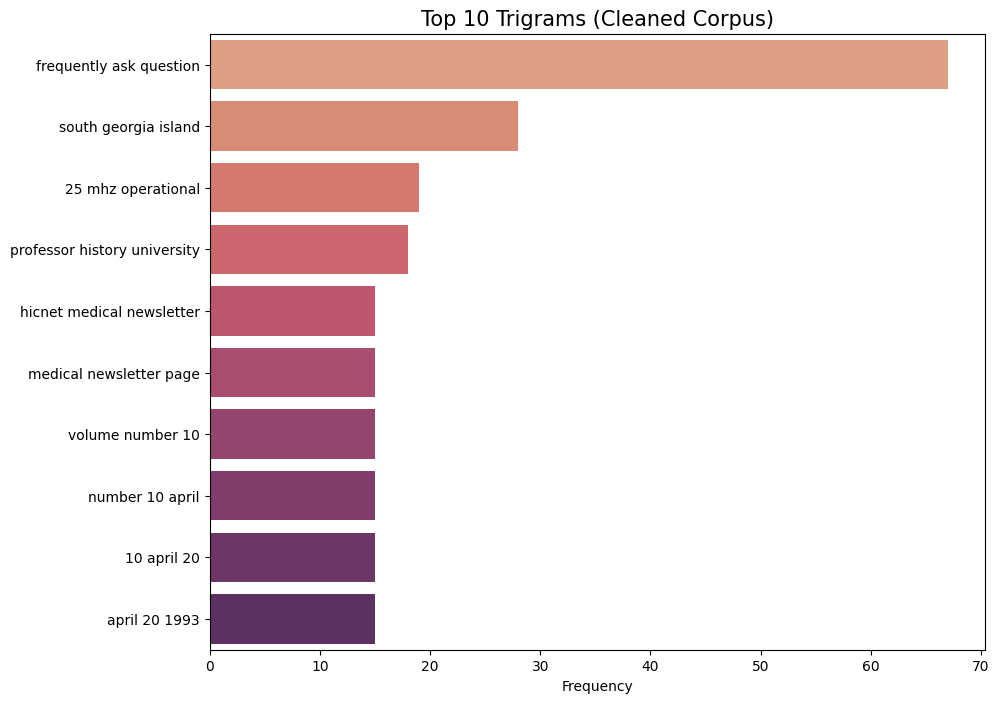

In [39]:
#Plotting Top 10 final cleaned corpus Trigrams
words, counts = zip(*top_trigrams_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="flare", legend=False)
plt.title("Top 10 Trigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

##### First Wordcloud for 20newsgroups

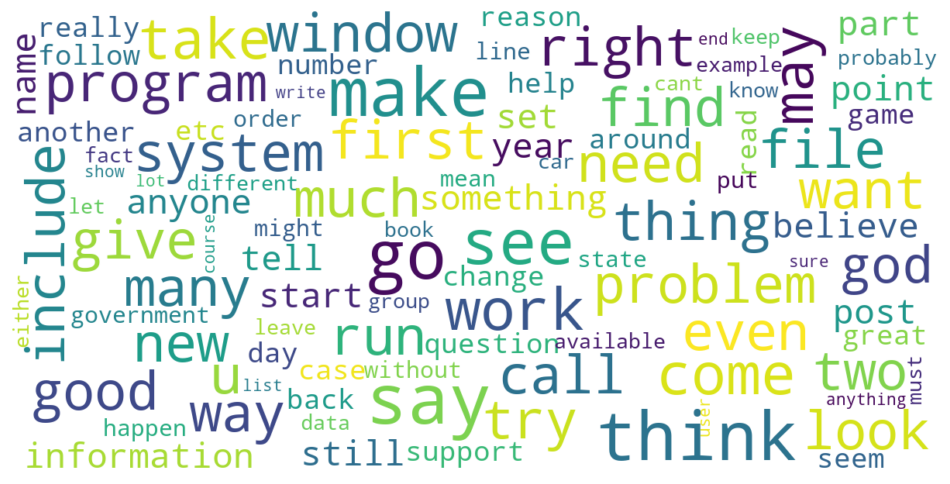

In [40]:
from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS)

def show_wordcloud(data):
    #Combining the list of strings into one single string (if it not already)
    if isinstance(data, pd.Series):
        text = ' '.join(data.astype(str))
    elif isinstance(data, list):
        text = ' '.join(data)
    else:
        text = str(data)

    
    #Configuring the WordCloud
    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1
    )

    #Generating the word cloud
    wordcloud.generate(text)

    #Plotting the image
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    plt.imshow(wordcloud, interpolation='bilinear') 
    plt.show()

#Calling the function with the corpus
show_wordcloud(corpus_20newsgroups)

##### Inserting custom words in the stopwords & removing them from 20newsgroups

In [41]:
#Defining custom filler words for adding in stopwords (found while running wordcloud & before adjusting in td-if max_df & min_df)
custom_words_to_ignore = [
    'many', 'take', 'need', 'say', 'may', 'much', 'find', 'thing', 
    'think', 'make', 'go', 'let', 'even', 'bit', 'way', 'quite', 
    'possible', 'enough', 'first', 'u', 'often', 'sometimes','iii10','reusss',
    'want','give','try','look','call','etc','example', 'something', 'anything',   
    'probably', 'seem', 'tell', 'want', 'good', 'right', 'know', 'really',
    'well', 'also', 'would', 'could', 'sure', 'lot','anyone'
]

#Updating the existing NLTK STOPWORDS set with the custom_words_to_ignore
stopwords = set(STOPWORDS)
STOPWORDS.update(custom_words_to_ignore)

#Creating an upgraded cleaning function
def remove_stopwords_and_numbers(text):
    """Custom function to remove stopwords, numbers, and single characters"""
    cleaned_words = []
    for word in str(text).split():
        #Skipping if the word is in the updated stopword list
        if word in STOPWORDS:
            continue
            
        #Skipping if the word is only 1 character long ('u', '1' etc)
        if len(word) <= 1:
            continue
        
        #Skipping any word that isn't 100% alphabetical letters ('42' etc)
        if not word.isalpha():
            continue
        
        #If it passes all rules, keeping the word
        cleaned_words.append(word)
        
    return " ".join(cleaned_words)

#Re-applying the upgraded function to the final base new text column final_checked_corpus
df_sentence_20newsgroups["final_checked_corpus"] = df_sentence_20newsgroups["final_clean_corpus"].apply(remove_stopwords_and_numbers)

#Updating corpus
corpus_20newsgroups = df_sentence_20newsgroups["final_checked_corpus"].tolist()
print("Text successfully re-cleaned! Numbers, mixed junk, and custom stopwords removed.")

Text successfully re-cleaned! Numbers, mixed junk, and custom stopwords removed.


##### Re-aligning final corpus with the original labels (category and ground truth)

In [42]:
#Keeping only rows where the cleaned text of column "final_lemmatized_cleaned_sentence" has length greater than 0
df_sentence_20newsgroups = df_sentence_20newsgroups[df_sentence_20newsgroups["final_checked_corpus"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "final_lemmatized_cleaned_sentence"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_sentence_20newsgroups)}")

#Re-aligning with the original labels (category and ground truth labels)
final_df_20newsgroups = df_sentence_20newsgroups.merge(
    full_df_20newsgroups[['ground_truth_label', 'category']], 
    left_index=True, 
    right_index=True
)


#Dropping duplicates based on both text and label
duplicate_count = final_df_20newsgroups.duplicated(subset=["final_checked_corpus", "ground_truth_label"]).sum()
print(f"Number of duplicate rows dropped: {duplicate_count}")
final_df_20newsgroups.drop_duplicates(subset=["final_checked_corpus", "ground_truth_label"], inplace=True)

#Resetting index
final_df_20newsgroups.reset_index(drop=True, inplace=True)
#Final rows in cleaned column after indxexing reset
print(f"Final rows in corpus column with name final_clean_corpus is: {len(final_df_20newsgroups)}")
print(f"Final rows in final merged dataframe of 20newsgroups: {len(final_df_20newsgroups)}")
print(f"Final shape for modeling: {final_df_20newsgroups.shape}")
print(' ')

#Updating corpus
corpus_20newsgroups=final_df_20newsgroups["final_checked_corpus"]

#display(final_df_20newsgroups.head())

Rows after removing empty rows in finally cleaned text column: 1819
Number of duplicate rows dropped: 1
Final rows in corpus column with name final_clean_corpus is: 1818
Final rows in final merged dataframe of 20newsgroups: 1818
Final shape for modeling: (1818, 8)
 


##### Final Topic Modelling for 20newsgroups

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model

#Grabbing latest cleaned corpus
corpus_final_20newsgroups = corpus_20newsgroups

#Re-vectorizing the text 
tf_vectorizer = CountVectorizer(stop_words=None,
                                max_df=0.85,    # Ignoring words that appear in >85% of documents
                                min_df=2,       # Ignoring words that appear in less than 2 documents
                                token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')
    
tf = tf_vectorizer.fit_transform(corpus_final_20newsgroups)

#Re-initializing and fit the LDA model for 8 topics. 20 had awful result
lda_model = LatentDirichletAllocation(n_components=8, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Displaying the dashboard
pyLDAvis.display(panel)

##### Final Wordcloud for 20newsgroups

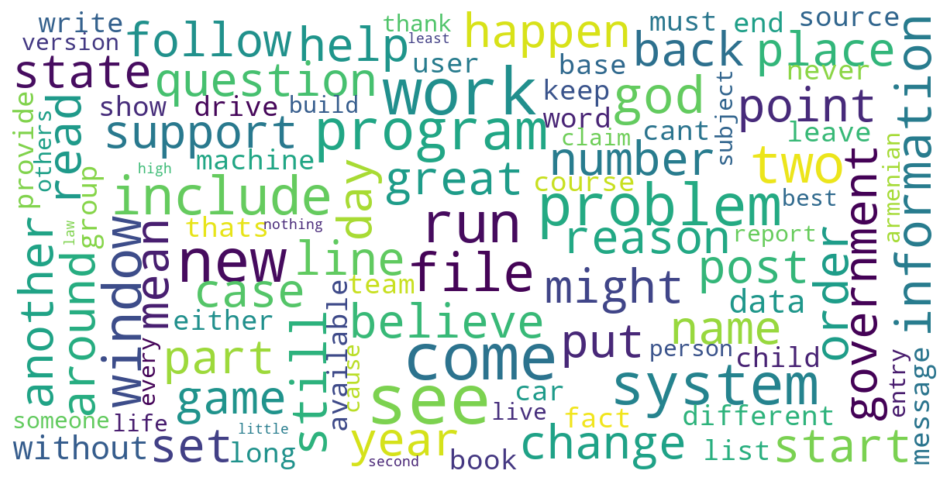

In [44]:
from wordcloud import WordCloud, STOPWORDS

#Calling the function with the final corpus
show_wordcloud(corpus_20newsgroups)

##### Visualizing updated distribution of word count per final cleaned sentence for 20newsgroups

Mean Word Count: 75.00
Median Word Count: 33.00


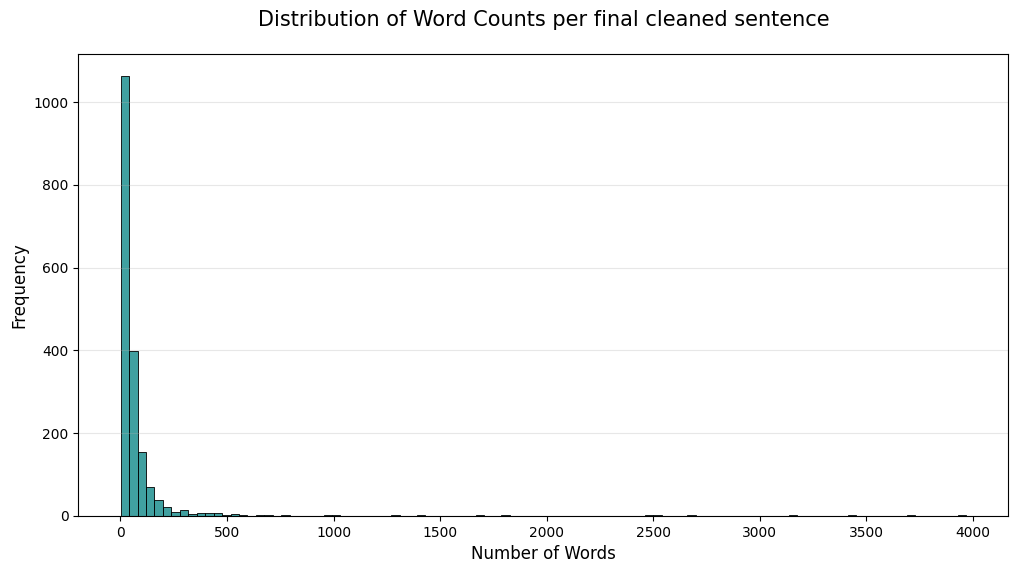

In [45]:
#Calculating updated word counts by splitting strings into lists
final_df_20newsgroups["word_count"] = final_df_20newsgroups["final_checked_corpus"].str.split().str.len()

#Calculating key statistics
mean_words = final_df_20newsgroups["word_count"].mean().round()
median_words = final_df_20newsgroups["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(final_df_20newsgroups["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per final cleaned sentence", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Visualizing updated Distribution of Article Lengths (Character Count) for 20newsgroups

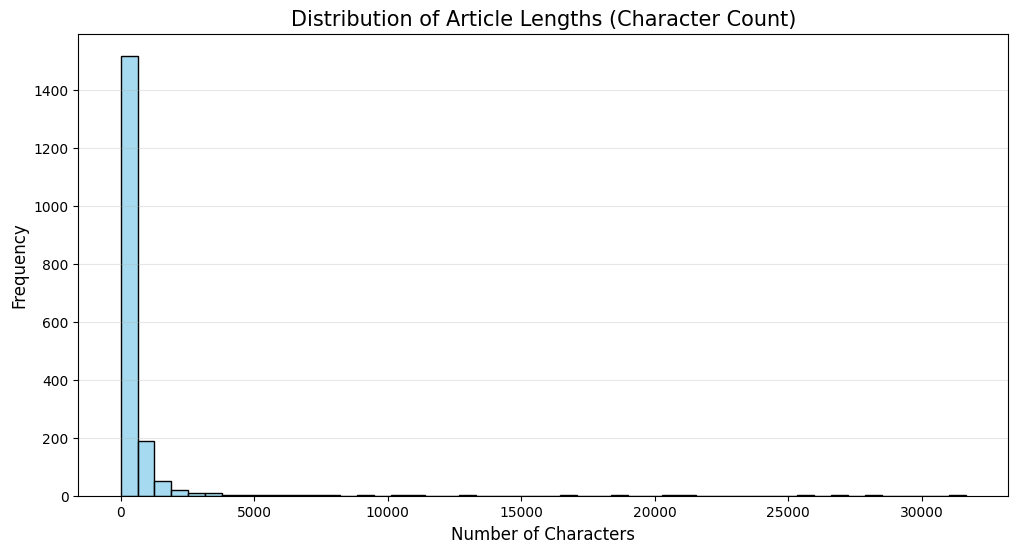

In [46]:
#Checking the number of characters present in each sentence to have a rough idea about the text headline length
#Calculating sentence lengths
final_df_20newsgroups["char_count"] = final_df_20newsgroups["final_checked_corpus"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(final_df_20newsgroups["char_count"], bins=50, color="skyblue")
plt.title("Distribution of Article Lengths (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Visualizing updated average word length in each Sentence for 20newsgroups

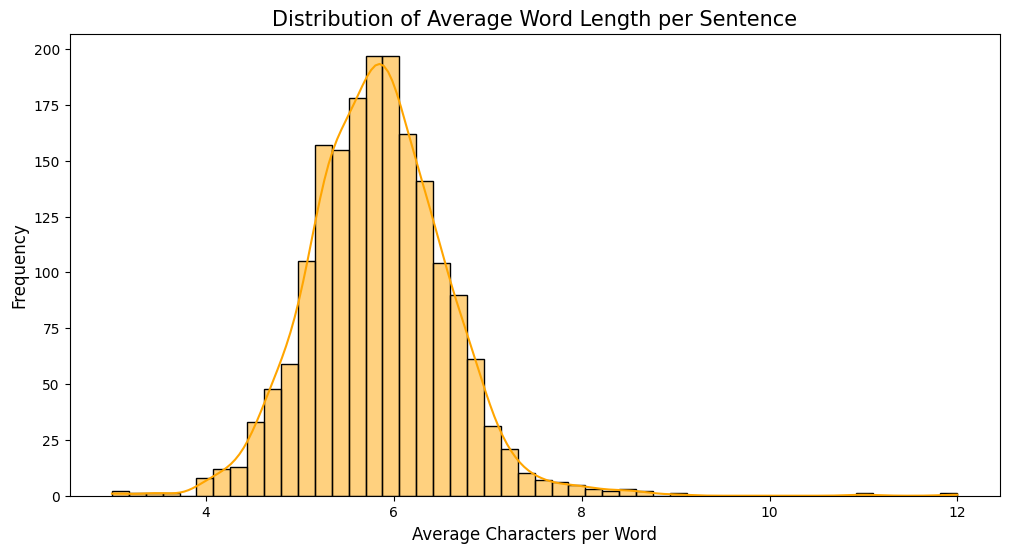

In [47]:
def get_avg_word_len(text):
    """Function to calculating average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

final_df_20newsgroups['avg_word_len'] = final_df_20newsgroups['final_checked_corpus'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(final_df_20newsgroups['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per Sentence", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()